# Customer Churn Analysis

## Objective
Predict whether a customer will churn based on their attributes.

## Dataset
Telco Customer Churn Dataset (Kaggle)

## Author
Taku Takahashi

In [ ]:
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df = df.drop("customerID", axis=1)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Initial Observations

- The dataset contains 7043 customers and 21 features
- The target variable is "Churn", indicating whether a customer left the service
- The dataset is moderately imbalanced:
  - ~73% customers did not churn
  - ~27% customers churned
- This imbalance suggests that accuracy alone may not be a reliable evaluation metric
- Several features appear to be categorical (object type), which will require encoding
- Further exploration is needed to understand relationships between features and churn

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

## Data Cleaning

- The `TotalCharges` column was incorrectly stored as an object type
- This was due to the presence of empty strings in the data
- Converted the column to numeric using `pd.to_numeric()`
- Missing values were introduced and subsequently removed
- Final dataset is now ready for analysis

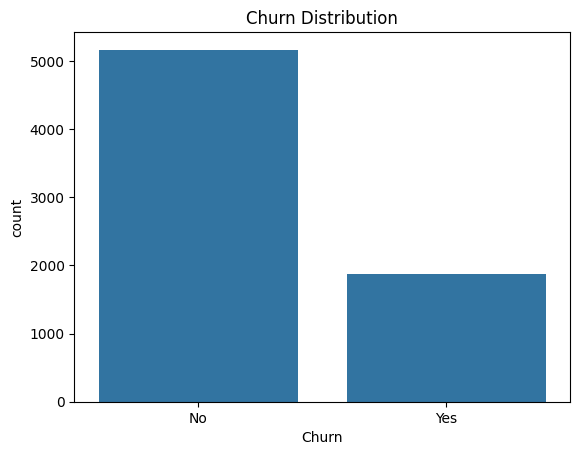

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

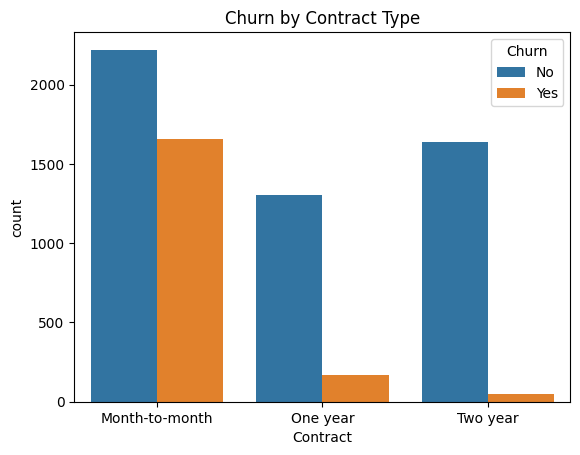

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

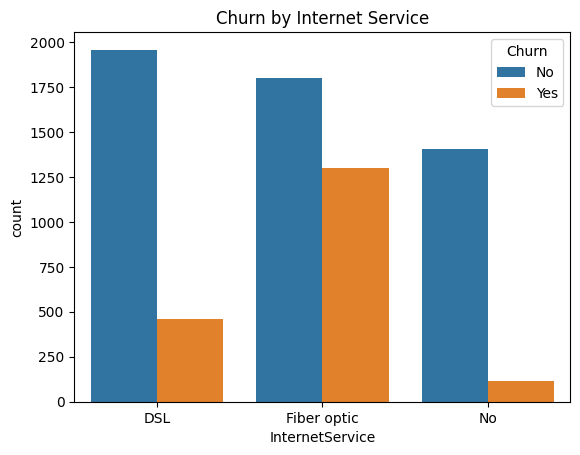

In [ ]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service")
plt.show()

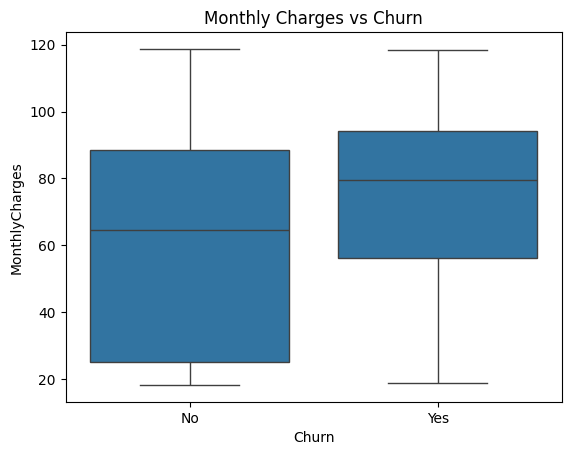

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

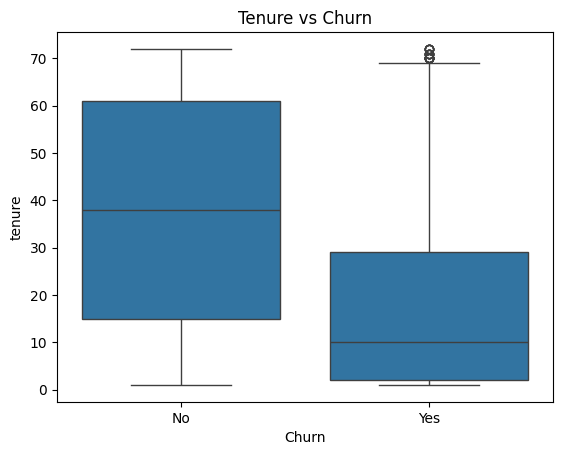

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

## EDA Insights

- Customers with month-to-month contracts have significantly higher churn rates compared to long-term contracts
- Customers with longer tenure are much less likely to churn, indicating that early-stage customers are at higher risk
- Higher monthly charges appear to be associated with increased churn
- Customers using fiber optic internet show higher churn rates compared to DSL users
- Overall, contract type and tenure appear to be the strongest predictors of churn

In [ ]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Baseline Model (Logistic Regression)

This model is trained without handling class imbalance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Baseline model
baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(X_train, y_train)

# Predictions
y_pred_base = baseline_model.predict(X_test)

# Evaluation
print("Baseline Model Performance:\n")
print(classification_report(y_test, y_pred_base))

Baseline Model Performance:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



/Users/tcasemiro/ds_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Improved Model (Class Balanced)

This model accounts for class imbalance by assigning higher weight to the minority class (churn).

In [ ]:
# Improved model
balanced_model = LogisticRegression(max_iter=2000, class_weight="balanced")
balanced_model.fit(X_train, y_train)

# Predictions
y_pred_balanced = balanced_model.predict(X_test)

# Evaluation
print("Balanced Model Performance:\n")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Performance:

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



/Users/tcasemiro/ds_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Model Comparison

- The baseline model achieved higher overall accuracy but had lower recall for churn
- The balanced model significantly improved recall for churn (from ~0.56 to ~0.76)
- This means the model is better at identifying customers who are likely to leave
- However, precision decreased, leading to more false positives
- This trade-off is acceptable because identifying churn is more important than avoiding false positives

### Conclusion
The balanced model is preferred because it better captures customers at risk of churning.

### Note
There is a trade-off between recall and precision, where improving recall increases the model’s ability to detect churners but also leads to more false positives.

In [ ]:
import pandas as pd

# Get coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": balanced_model.coef_[0]
})

# Sort by importance
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.094657
8,MultipleLines_No phone service,0.549895
23,StreamingMovies_Yes,0.381856
21,StreamingTV_Yes,0.371989
28,PaymentMethod_Electronic check,0.283456
9,MultipleLines_Yes,0.259466
0,SeniorCitizen,0.256539
26,PaperlessBilling_Yes,0.250418
7,PhoneService_Yes,0.241273
5,Partner_Yes,0.038772


In [ ]:
coefficients.tail(10)

,Feature,Coefficient
18,TechSupport_No internet service,-0.158995
20,StreamingTV_No internet service,-0.158995
22,StreamingMovies_No internet service,-0.158995
12,OnlineSecurity_No internet service,-0.158995
11,InternetService_No,-0.158995
6,Dependents_Yes,-0.213877
19,TechSupport_Yes,-0.333177
13,OnlineSecurity_Yes,-0.363327
24,Contract_One year,-0.795734
25,Contract_Two year,-1.382822


## Feature Importance Insights

- Fiber optic internet users show the highest likelihood of churn, possibly due to higher costs or expectations
- Customers using additional services (streaming, multiple lines) tend to churn more, suggesting that higher engagement may increase dissatisfaction risk
- Customers using electronic check payment methods are more likely to churn, indicating lower commitment
- Customers with no internet service or with dependents are less likely to churn, suggesting more stable customer segments
- These findings partially align with earlier EDA results, especially regarding service type and customer behavior

## Business Interpretation of Key Features

### Fiber Optic Customers

Fiber optic customers are typically high-value users who pay more and use more services. Because of this, they have higher expectations for performance and service quality. When these expectations are not met, dissatisfaction is amplified, especially given the higher cost. This makes them more likely to churn.

Additionally, these customers may have more alternatives available in the market, making it easier for them to switch providers.

---

### Key Takeaway

Customer churn is not only driven by service type, but by the combination of:
- High expectations
- Higher pricing
- Customer experience

This highlights the importance of maintaining service quality for premium customers.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Random Forest Performance:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Tuned Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Tuned Random Forest:

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.76      1407



In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.185509
3,TotalCharges,0.135911
25,Contract_Two year,0.106641
2,MonthlyCharges,0.094015
10,InternetService_Fiber optic,0.072919
28,PaymentMethod_Electronic check,0.050519
24,Contract_One year,0.044951
13,OnlineSecurity_Yes,0.039711
19,TechSupport_Yes,0.026989
12,OnlineSecurity_No internet service,0.018511


## Random Forest Results

- The tuned Random Forest model achieved similar performance to Logistic Regression
- Recall for churn improved significantly compared to the baseline model (~0.73), but did not surpass Logistic Regression
- This suggests that the relationship between features and churn may be relatively linear

## Feature Importance Insights

- Tenure is the most important predictor, confirming that newer customers are more likely to churn
- Contract type (especially two-year contracts) strongly reduces churn
- Higher charges (monthly and total) are associated with churn behavior
- Fiber optic customers show higher churn risk, consistent with earlier analysis

Overall, the Random Forest model supports the findings from both EDA and Logistic Regression

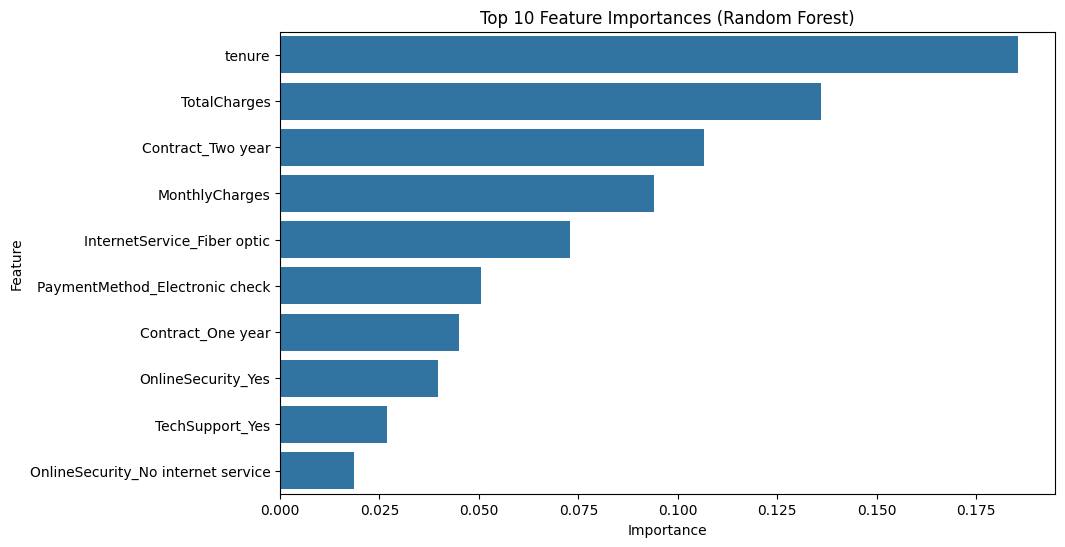

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 features
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Feature Importance Visualization

The plot above highlights the most important features influencing customer churn.

- Tenure is the strongest predictor, indicating that newer customers are at higher risk
- Contract type plays a major role, with long-term contracts reducing churn
- Pricing variables (MonthlyCharges, TotalCharges) are also significant
- Service-related features such as Fiber optic internet contribute to churn behavior

# Final Project Summary

## Objective
The goal of this project was to analyze and predict customer churn using a telecom dataset, and to identify key factors driving customer retention and loss.

## Approach
- Performed data cleaning and preprocessing
- Conducted exploratory data analysis to identify patterns
- Built Logistic Regression and Random Forest models
- Addressed class imbalance using class weighting
- Evaluated models using precision, recall, and F1-score

## Key Findings
- Customers with month-to-month contracts are significantly more likely to churn
- New customers (low tenure) are at the highest risk of leaving
- Higher-paying customers (especially fiber optic users) tend to churn more
- Payment method and service usage patterns influence churn behavior

## Model Insights
- Logistic Regression and Random Forest performed similarly
- Recall was prioritized to better detect customers likely to churn
- The final model effectively identifies high-risk customers, enabling targeted retention strategies

## Business Impact
- Companies should focus on early-stage customers to reduce churn
- Improving service quality for premium users (fiber optic) is critical
- Encouraging long-term contracts can significantly reduce churn

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure images folder exists (safe even if it already exists)
os.makedirs("images", exist_ok=True)

# Example: plot top 10 features (make sure top_features exists)
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top_features)

plt.title("Top 10 Feature Importances")

# Save image
plt.savefig("images/feature_importance.png", bbox_inches="tight")

plt.show()